# **Assignment 1: Demand prediction of bike sharing system**

Bike sharing services are nowadays spread all over the world. They are beneficial for cities as they offer a climate neutral and healthy way of transportation. Moreover, similar to e-scooters, for the companies and transportation researchers they generate valuable data. This includes the trip route, trip origins and destinations, duration, and much more.

In this assignment we use a public bike sharing dataset from Washington, D.C., USA. published by Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.

## Your Task

Your task in this assignment is:

1) to predict the demand of hourly rentals (**target-column: cnt**) using the [XGBoost](https://xgboost.readthedocs.io/en/stable/) and linear regression model. In this notebook we have provided you with the basic structure how to approach the problem. Feel free to reuse and improve parts of the exercise material.

2) After you have created the model please upload your code to Github and post the link to the notebook in the corresponding forum for the assignment with a short text describing how you have solved the task.

## Load data

You can also find more information about the data and the columns at: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [24]:
import pandas as pd

url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
df = pd.read_csv(url)

#df = pd.read_csv('Exercise2BikeSharing.csv')
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [25]:
df.shape

(17379, 17)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Train / Test split
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

In [27]:
from sklearn.model_selection import train_test_split
target = 'cnt'

X = df.copy()
y = df[target].astype(float)

X.drop(columns=[target], inplace=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Data Processing / Feature Engineering

Before training the model think about data processing and feature engineering steps if applicable, such as:
- adding/removal of features
- normalization
- one hot encoding
- ...


In [28]:
# Your code here
df.columns
# Either drop Irrelevant Features or keep the ones mentioned above

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [29]:
drop_cols = ['instant', 'dteday', 'casual', 'registered']

X_train_processed = X_train.drop(columns=drop_cols, errors='ignore').copy()
X_test_processed = X_test.drop(columns=drop_cols, errors='ignore').copy()

In [34]:
#df
df = df[['cnt','temp', 'atemp','hum', 'windspeed', 'weathersit','hr','weekday','workingday','holiday','season','yr']]

In [35]:
corr_matrix=df.corr()
corr_matrix['cnt'].sort_values(ascending=False)

,cnt
cnt,1.000000
temp,0.404772
atemp,0.400929
hr,0.394071
yr,0.250495
season,0.178056
windspeed,0.093234
workingday,0.030284
weekday,0.026900
holiday,-0.030927


## Hyperparameter optimization
Hyperparameter tuning helps find the best set of hyperparameters for your model. Use Grid Search or Random Search with Cross Validation from scikit-learn to search for the best combination of parameters.

In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd

# Explicitly define feature lists and drop_cols to ensure they are available in this cell's scope
numerical_features = ['temp', 'atemp', 'hum', 'windspeed']
categorical_features = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
drop_cols = ['instant', 'dteday', 'casual', 'registered']

# Re-apply the column drops to X_train and X_test here for completeness
# (assuming X_train and X_test are already in kernel state from previous cells)
X_train_processed = X_train.drop(columns=drop_cols, errors='ignore').copy()
X_test_processed = X_test.drop(columns=drop_cols, errors='ignore').copy()

# Define the preprocessing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='drop' # Explicitly drop any columns not specified
)

# Apply the preprocessing to X_train_processed and X_test_processed
X_train_processed_array = preprocessor.fit_transform(X_train_processed)
X_test_processed_array = preprocessor.transform(X_test_processed)

# Get feature names after one-hot encoding using the fitted preprocessor
all_processed_features = preprocessor.get_feature_names_out()

# Convert processed arrays back to DataFrame
X_train_processed_df = pd.DataFrame(X_train_processed_array, columns=all_processed_features, index=X_train_processed.index)
X_test_processed_df = pd.DataFrame(X_test_processed_array, columns=all_processed_features, index=X_test_processed.index)


# Define a parameter grid for hyperparameter tuning
param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [ 1, 10],
    'epsilon': [ 1, 10]
}

# Create the GridSearchCV object
grid_search = GridSearchCV(SVR(), param_grid, cv=5, verbose=2)

# Fit the grid search to the preprocessed training data
grid_search.fit(X_train_processed_df, y_train)

# Get the best parameters
best_params = grid_search.best_params_

print("Best Parameters:", best_params)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END ......................C=1, epsilon=1, kernel=linear; total time=   5.1s
[CV] END ......................C=1, epsilon=1, kernel=linear; total time=   5.1s
[CV] END ......................C=1, epsilon=1, kernel=linear; total time=   4.7s
[CV] END ......................C=1, epsilon=1, kernel=linear; total time=   5.3s
[CV] END ......................C=1, epsilon=1, kernel=linear; total time=   4.7s
[CV] END .........................C=1, epsilon=1, kernel=rbf; total time=   7.9s
[CV] END .........................C=1, epsilon=1, kernel=rbf; total time=   8.4s
[CV] END .........................C=1, epsilon=1, kernel=rbf; total time=   7.8s
[CV] END .........................C=1, epsilon=1, kernel=rbf; total time=   9.3s
[CV] END .........................C=1, epsilon=1, kernel=rbf; total time=   8.3s
[CV] END .....................C=1, epsilon=10, kernel=linear; total time=   4.2s
[CV] END .....................C=1, epsilon=10, ke

## Train the XGBoost and Linear regression models
Now, create an XGBoost and linear regression model using the best parameters and train them using the training data.

In [42]:
# Your code here
import xgboost as xgb
from sklearn.linear_model import LinearRegression

# Initialize XGBoost Regressor
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)

# Train XGBoost model
print("Training XGBoost model...")
xgb_model.fit(X_train_processed_df, y_train)
print("XGBoost model training complete.")

# Initialize Linear Regression model
linear_model = LinearRegression()

# Train Linear Regression model
print("Training Linear Regression model...")
linear_model.fit(X_train_processed_df, y_train)
print("Linear Regression model training complete.")

Training XGBoost model...
XGBoost model training complete.
Training Linear Regression model...
Linear Regression model training complete.


## Make predictions
Use the trained models to make predictions on the test data and compare the performance of the XGBoost and linear regression models using metrics like Mean Squared Error (MSE) and R-squared.

In [43]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions with XGBoost model
xgb_predictions = xgb_model.predict(X_test_processed_df)

# Evaluate XGBoost model
xgb_mse = mean_squared_error(y_test, xgb_predictions)
xgb_r2 = r2_score(y_test, xgb_predictions)

print("XGBoost Model Performance:")
print(f"Mean Squared Error (MSE): {xgb_mse:.2f}")
print(f"R-squared (R2): {xgb_r2:.2f}")
print("\n")

# Make predictions with Linear Regression model
linear_predictions = linear_model.predict(X_test_processed_df)

# Evaluate Linear Regression model
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Model Performance:")
print(f"Mean Squared Error (MSE): {linear_mse:.2f}")
print(f"R-squared (R2): {linear_r2:.2f}")

XGBoost Model Performance:
Mean Squared Error (MSE): 2039.03
R-squared (R2): 0.94


Linear Regression Model Performance:
Mean Squared Error (MSE): 10089.39
R-squared (R2): 0.68


## Visualize the predictions and compare the mdoels
Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

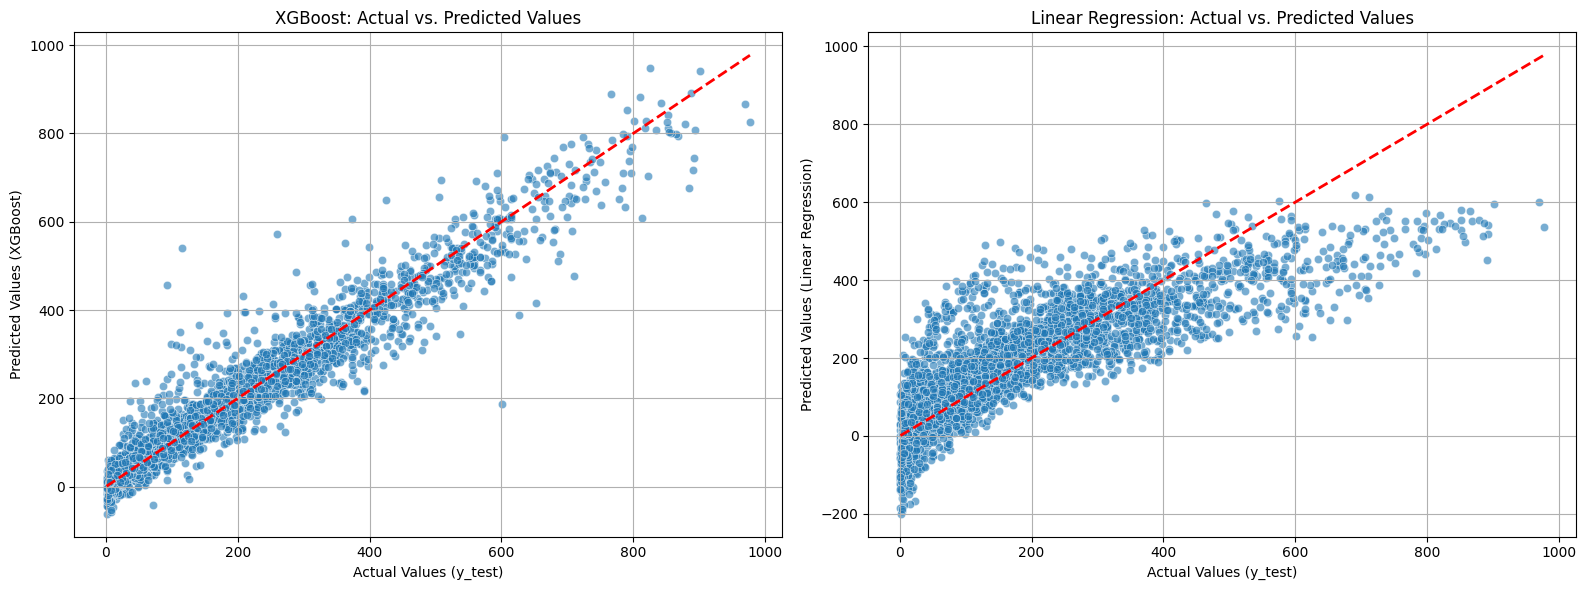

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for XGBoost Model
sns.scatterplot(x=y_test, y=xgb_predictions, ax=axes[0], alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('XGBoost: Actual vs. Predicted Values')
axes[0].set_xlabel('Actual Values (y_test)')
axes[0].set_ylabel('Predicted Values (XGBoost)')
axes[0].grid(True)

# Plot for Linear Regression Model
sns.scatterplot(x=y_test, y=linear_predictions, ax=axes[1], alpha=0.6)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title('Linear Regression: Actual vs. Predicted Values')
axes[1].set_xlabel('Actual Values (y_test)')
axes[1].set_ylabel('Predicted Values (Linear Regression)')
axes[1].grid(True)

plt.tight_layout()
plt.show()